In [1]:
import pandas as pd
import seaborn as  sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    roc_curve, roc_auc_score
)
import joblib

### **Load Dataset**

In [2]:
df=pd.read_csv('D:\\Github\\Artificial-Intelligence-Labs\\Loan Approval Prediction\\data\\raw\\train.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


### **EDA**

In [6]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [10]:
missing=df.isna().sum().sort_values(ascending=False)
missing[missing>0]

Credit_History      50
Self_Employed       32
LoanAmount          22
Dependents          15
Loan_Amount_Term    14
Gender              13
Married              3
dtype: int64

In [15]:
df['Loan_Status'].value_counts(dropna=False)
df['Loan_Status'].value_counts(normalize=True, dropna=False)

Loan_Status
Y    0.687296
N    0.312704
Name: proportion, dtype: float64

In [ ]:
df['Credit_History'].value_counts()
df['Loan_Status'].isna().value_counts()

Credit_History
1.0    475
0.0     89
Name: count, dtype: int64

### **Visualization**

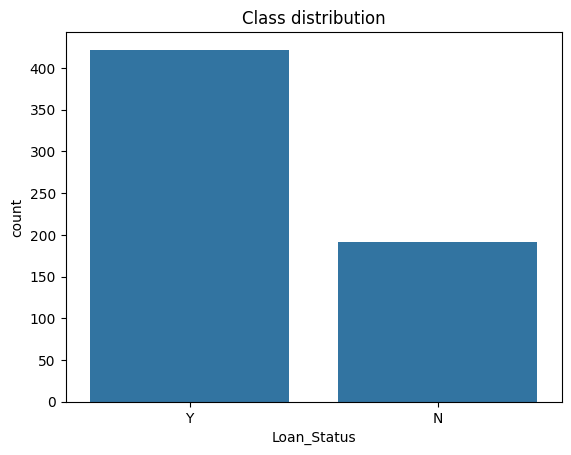

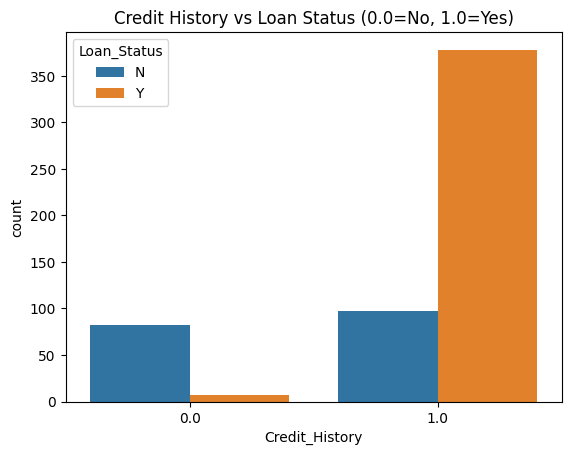

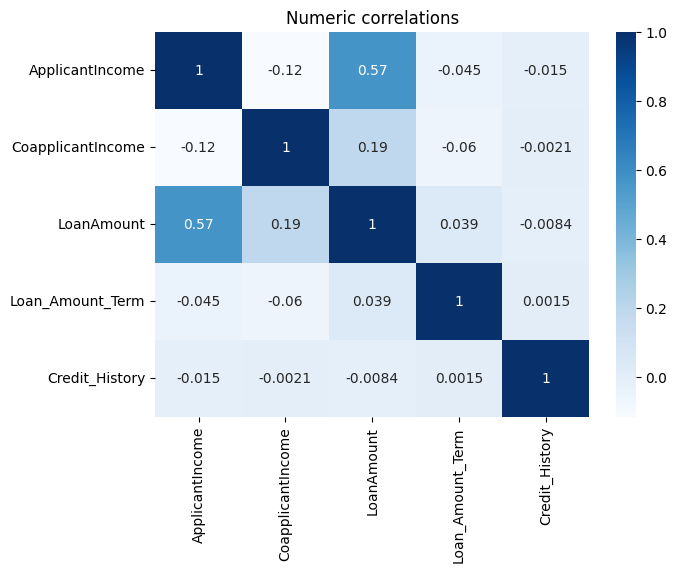

In [23]:
sns.countplot(data=df, x="Loan_Status")
plt.title("Class distribution")
plt.show()

sns.countplot(data=df, x="Credit_History", hue="Loan_Status")
plt.title("Credit History vs Loan Status (0.0=No, 1.0=Yes)")
plt.show()

num_df = df.select_dtypes(include=["int64","float64"])
plt.figure(figsize=(7,5))
sns.heatmap(num_df.corr(numeric_only=True), annot=True, cmap="Blues")
plt.title("Numeric correlations")
plt.show()


### **Preprocessing**
Use a single sklearn `Pipeline` with a `ColumnTransformer` so your training preprocessing is identical to deployment preprocessing.

In [41]:
if 'Loan_ID' in df.columns:
    df=df.drop(columns=['Loan_ID'])

y=(df['Loan_Status']=='Y').astype(int)
X=df.drop(columns=['Loan_Status'])

X_temp, X_test, y_temp, y_test = train_test_split( X, y, test_size=0.20, random_state=42, stratify=y)
X_train, X_val, y_train, y_val=train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

num_cols=X_train.select_dtypes(include=['int64','float64']).columns
cat_cols=X_train.select_dtypes(include=['object']).columns

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols),
])

### **Training and Tuning**
DecisionTreeClassifier supports `criterion` and regularization knobs like `max_depth` and `min_samples_split` (controlling these is your main overfitting lever).

In [42]:
def build_model(**dt_params):
    return Pipeline([("prep", preprocess),
        ("dt", DecisionTreeClassifier(random_state=42, **dt_params))
        ])

grid={
    "criterion":["gini","entropy"],
    "max_depth":[3,5,7,None],
    "min_samples_split": [2,10,20]
}


best={'auc':-1, 'params':None, 'model':None}

for crit in grid['criterion']:
    for md in grid["max_depth"]:
        for mss in grid['min_samples_split']:
            model=build_model(criterion=crit, max_depth=md, min_samples_split=mss)
            model.fit(X_train, y_train)
            val_proba=model.predict_proba(X_val)[:,1]
            auc=roc_auc_score(y_val, val_proba)
            if auc > best['auc']:
                best={"auc": auc, "params": {"criterion": crit, "max_depth": md, "min_samples_split": mss}, "model": model}

best


{'auc': 0.7678571428571429,
 'params': {'criterion': 'gini', 'max_depth': 7, 'min_samples_split': 20},
 'model': Pipeline(steps=[('prep',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median'))]),
                                                   Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
        'Loan_Amount_Term', 'Credit_History'],
       dtype='object')),
                                                  ('cat',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='most_frequent')),
                                                                   ('onehot',
                                                                    OneHotEncoder(handle_unknown='ignore'))]),


### **Evaluation**

Accuracy: 0.8292682926829268
Confusion matrix:
 [[22 16]
 [ 5 80]]
              precision    recall  f1-score   support

Not Approved       0.81      0.58      0.68        38
    Approved       0.83      0.94      0.88        85

    accuracy                           0.83       123
   macro avg       0.82      0.76      0.78       123
weighted avg       0.83      0.83      0.82       123



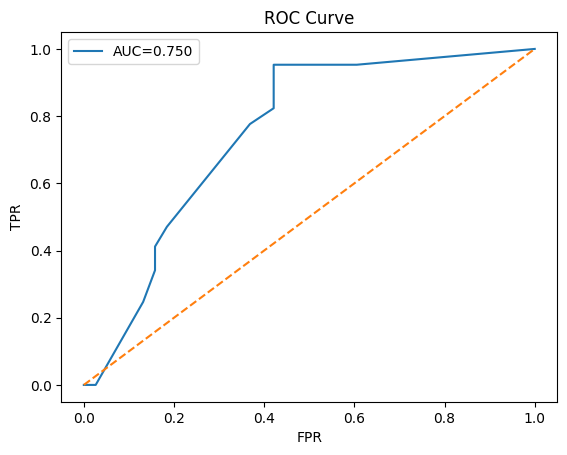

In [43]:
# Retrain on train+val with best params
X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

final_model = build_model(**best["params"]).fit(X_trainval, y_trainval)

# Predictions
test_pred = final_model.predict(X_test)
test_proba = final_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, test_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, test_pred))
print(classification_report(y_test, test_pred, target_names=["Not Approved","Approved"]))

# ROC
fpr, tpr, _ = roc_curve(y_test, test_proba)
auc = roc_auc_score(y_test, test_proba)
plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
plt.plot([0,1], [0,1], "--")
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC Curve"); plt.legend(); plt.show()


### **Saving Model**

In [44]:
joblib.dump(final_model, "D:\\Github\\Artificial-Intelligence-Labs\\Loan Approval Prediction\\model\\loan_tree.pkl")

['D:\\Github\\Artificial-Intelligence-Labs\\Loan Approval Prediction\\model\\loan_tree.pkl']



----
## Why these scores are good
An accuracy of ~0.83 on the test set means the model gets most applications correct, and your weighted F1 (~0.82) suggests that performance is not coming only from one class. The classification report summarizes precision/recall/F1 per class plus macro/weighted averages, so you can argue “overall” performance and also “per-class” behavior. [scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)

## What the confusion matrix says
In scikit-learn, the confusion matrix is arranged so \(C_{i,j}\) counts items with true class \(i\) predicted as class \(j\); for binary, you can read TN at \(C_{0,0}\), FP at \(C_{0,1}\), FN at \(C_{1,0}\), and TP at \(C_{1,1}\). [scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)
Your matrix `[[22,16],[5,80]]` shows **high recall for Approved** (80 out of 85 approvals caught) but more errors on Not Approved (16 false approvals out of 38 rejections), which is a realistic tradeoff in lending tasks. [scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)

## Why the per-class metrics look strong
Approved class recall is 0.94, which means very few “should be approved” applicants are rejected by the model (low false negatives). Precision and recall are exactly what they sound like—precision is “when we predict Approved, how often are we right,” while recall is “out of all truly Approved, how many did we catch”—and F1 balances them into one number. [pythontutorials](https://www.pythontutorials.net/blog/classification-report-sklearn/)

## AUC comment (and one caution)
A validation AUC around 0.77 suggests the model has decent ranking power (it tends to assign higher scores to Approved than Not Approved), and ROC-AUC is commonly interpreted on a 0–1 scale where 0.5 is no better than random and 1.0 is perfect separation. [sklearner](https://sklearner.com/scikit-learn-roc_auc_score/)
The caution: your Not Approved recall is 0.58, meaning you still miss a good chunk of rejections; in a bank setting that can be costly (more false approvals), so later you can tune the decision threshold or use class weights—but as a university lab baseline, this is already solid.

